In [1]:
from spin_lattices import KagomeLattice
from heisenberg_hamiltonians import HeisenbergJ1J2, SpinSystem
from boolean_analysis import BooleanFourierAnalyser, keep_largest_n
from pathlib import Path
import numpy as np
import pandas as pd
import lattice_symmetries as ls
import matplotlib.pyplot as plt
from heisenberg_hamiltonians import batched_state_info_df
from itertools import product
import numpy.typing as npt
from tqdm import tqdm
import seaborn as sns

%matplotlib widget

2023-01-18 13:21:33.517 | DEBUG    | lattice_symmetries:__init__:49 - Initializing Haskell runtime...
2023-01-18 13:21:33.521 | DEBUG    | lattice_symmetries:__init__:51 - Initializing Chapel runtime...
[Debug]   [LOCALE0]   Initializing chpl_kernels ...
2023-01-18 13:21:33.549 | DEBUG    | lattice_symmetries:__init__:53 - Setting Python exception handler...
set_python_exception_handler ...


## Test various learning modes

Is it true that learning on high-probable configurations is better?

In [2]:
J2 = 0.8
system = HeisenbergJ1J2(
    KagomeLattice(width=2, height=2),
    J1=1,
    J2=J2,
    use_symmetries=True,
    spin_inversion=1,
    ground_state_cache_dir=Path("groundstates"),
)
analyzer = BooleanFourierAnalyser(
    system=system,
    use_subset_symmetries=True,
)


number_spins=12
Symmetry group contains 16 elements
Hilbert space dimension is 47
Finding system ground state
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x2-1.0-0.8-True-1-1.pickle
Ground state energy is -20.0382298203


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


In [6]:
batched_state_info_df(system.basis, system.canonical_basis.states)

,representative,character,norm
63,63,1.0+0.0j,0.176777
95,95,1.0+0.0j,0.250000
111,63,1.0-0.0j,0.176777
119,119,1.0+0.0j,0.176777
123,95,1.0-0.0j,0.250000
...,...,...,...
3972,95,1.0-0.0j,0.250000
3976,119,1.0-0.0j,0.176777
3984,63,1.0-0.0j,0.176777
4000,95,1.0-0.0j,0.250000


In [56]:
J2 = 0.8
system = HeisenbergJ1J2(
    KagomeLattice(width=2, height=4),
    J1=1,
    J2=J2,
    use_symmetries=True,
    spin_inversion=1,
    ground_state_cache_dir=Path("groundstates"),
)

test_set = system.sample_elements(
    representatives=system.basis.states,
    n=1000,
)
results = []
for J2 in tqdm([
        0.0,
        0.2,
        0.4,
        0.5,
        0.55,
        0.6,
        0.65,
        0.7,
        0.75,
        0.8,
        0.85,
        0.9,
        0.95,
        1.0,
    ]):
    system = HeisenbergJ1J2(
        KagomeLattice(width=2, height=4),
        J1=1,
        J2=J2,
        use_symmetries=True,
        spin_inversion=1,
        ground_state_cache_dir=Path("groundstates"),
    )
    system.get_eigenstates(1)
    amplitude = system.get_df_eigenstate(0, canonical_basis=True)["amplitude"]
    ground_state_prob = amplitude ** 2

    for train_set_sampling, keep_largest in product(["uniform", "ground_state"], [1, 10, 100]):
        analyzer = BooleanFourierAnalyser(system=system)

        train_set = system.sample_elements(
            representatives=np.setdiff1d(
                analyzer.system.basis.states, analyzer.system.basis.state_info(test_set)[0]
            ),
            n=1000,
            prob=ground_state_prob
            if train_set_sampling == "ground_state"
            else (amplitude > 5e-6) * 1,
        )

        assert (
            len(
                np.intersect1d(
                    system.basis.state_info(train_set)[0], system.basis.state_info(test_set)[0]
                )
            )
            == 0
        )

        analyzer.fit(train_set)
        scores = analyzer.set_truncate_strategy(keep_largest_n(keep_largest)).prediction_score(
            test_set, scorer=["accuracy", "overlap"]
        )
        results.append(
            {"J2": J2, "train_set_sampling": train_set_sampling, "keep_largest": keep_largest}
            | scores
        )
results = pd.DataFrame(results)



number_spins=24
Symmetry group contains 16 elements
Hilbert space dimension is 85662


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
  0%|          | 0/14 [00:00<?, ?it/s][Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


number_spins=24
Symmetry group contains 16 elements
Hilbert space dimension is 85662
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x4-1.0-0.0-True-1-1.pickle
Ground state energy is -46.1341392314


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Finding system ground state
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x4-1.0-0.0-True-1-1.pickle
Ground state energy is -46.1341392314


...

[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Finding system ground state
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x4-1.0-1.0-True-1-1.pickle
Ground state energy is -42.8245991763


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Finding system ground state
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x4-1.0-1.0-True-1-1.pickle
Ground state energy is -42.8245991763


100%|██████████| 14/14 [51:40<00:00, 221.47s/it]


In [11]:
%matplotlib inline

In [61]:
results

,J2,train_set_sampling,keep_largest,accuracy,overlap
0,0.0,uniform,1,1.000,1.000000
1,0.0,uniform,10,0.733,0.305722
2,0.0,uniform,100,0.572,0.150960
3,0.0,ground_state,1,1.000,1.000000
4,0.0,ground_state,10,0.712,0.977347
...,...,...,...,...,...
79,1.0,uniform,10,0.506,-0.123159
80,1.0,uniform,100,0.507,0.463811
81,1.0,ground_state,1,0.253,0.164261
82,1.0,ground_state,10,0.527,0.381048


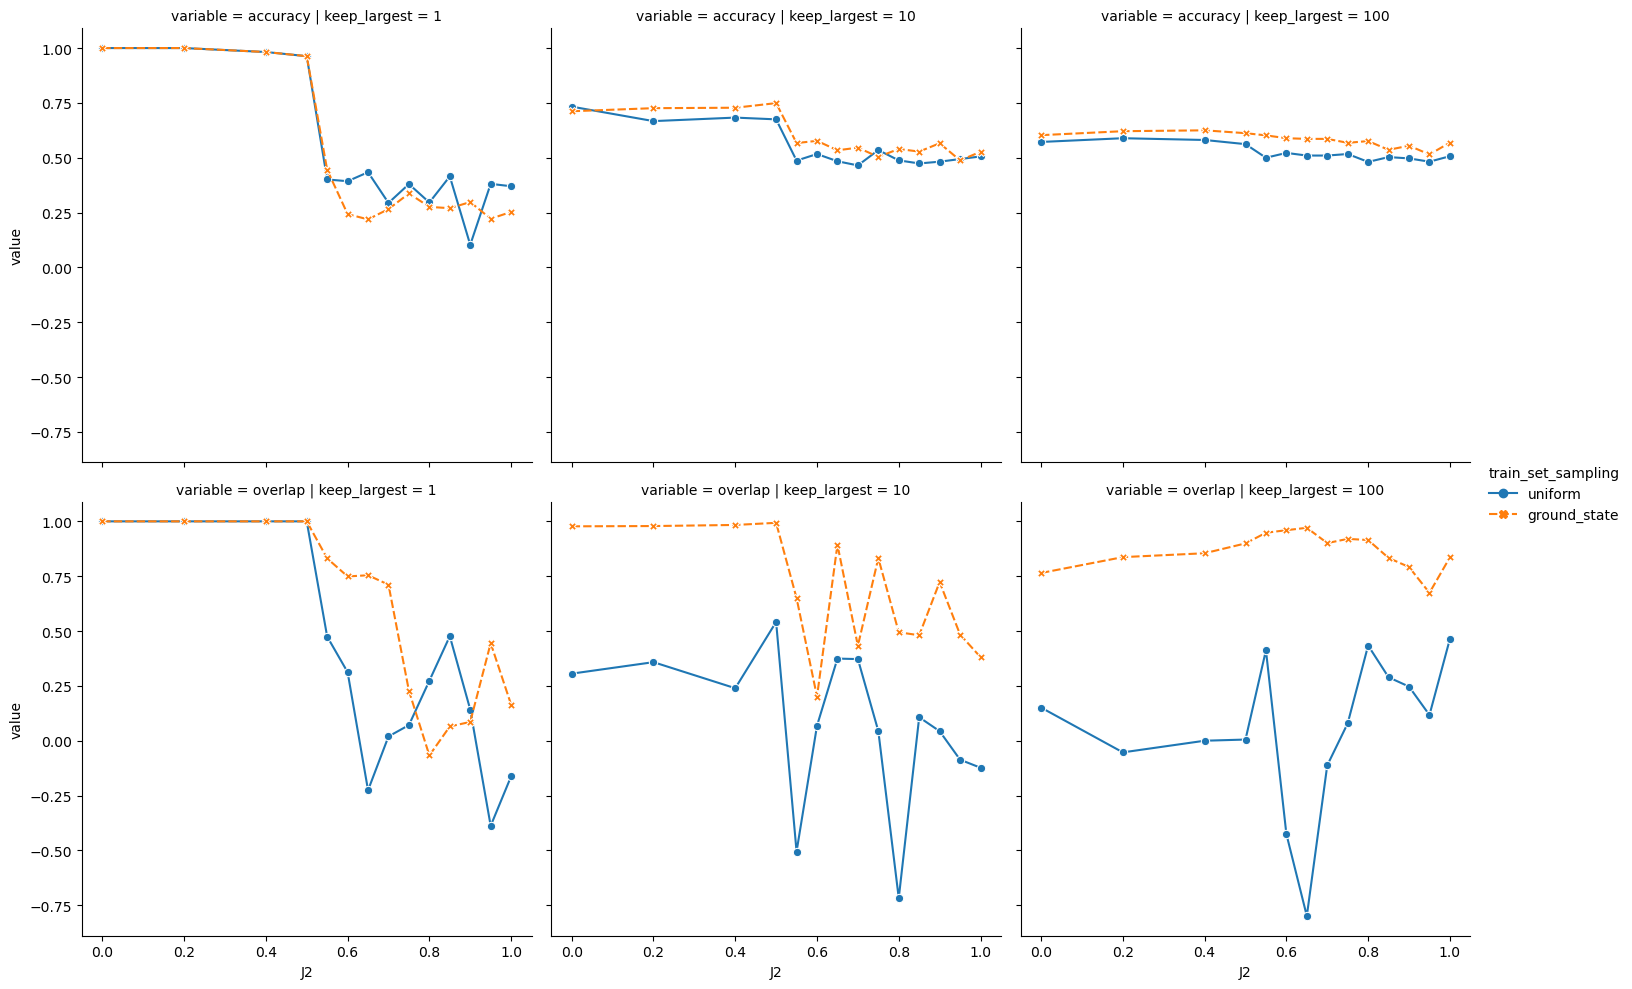

In [60]:
sns.relplot(
    data=results.melt(
        id_vars=["J2", "train_set_sampling", "keep_largest"], value_vars=["accuracy", "overlap"]
    ),
    x="J2",
    y="value",
    hue="train_set_sampling",
    col="keep_largest",
    row="variable",
    kind="line",
    style="train_set_sampling",
    markers=True,
)


In [28]:
from boolean_analysis import overlap_scorer, accuracy_scorer

In [17]:
J2 = 0.8
system = HeisenbergJ1J2(
    KagomeLattice(width=2, height=4),
    J1=1,
    J2=J2,
    use_symmetries=True,
    spin_inversion=1,
    ground_state_cache_dir=Path("groundstates"),
)

test_set = sample_elements(
    system=system,
    representatives=system.basis.states,
    n=1000,
)

number_spins=24
Symmetry group contains 16 elements
Hilbert space dimension is 85662


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


In [31]:
system.get_eigenstates(1)
true = system.get_df_ground_state().assign(y=lambda x: np.sign(x['eigenstate_coeff']), prob=lambda x: x['amplitude']**2)
predict = -np.ones_like(true['eigenstate_coeff'])
overlap_scorer(true, predict)

Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x4-1.0-0.8-True-1-1.pickle
Ground state energy is -40.5183420067


-0.0008872500648159098

In [35]:
set(system.basis.state_info(train_set)[0]) & set(system.basis.state_info(test_set)[0])

{422365, 422750, 1471410, 1689548, 1700696, 1755962, 1759064, 5449421}